# Home Credit Default Risk — In-Class Competition Solution

**Author:** Brandon Uriel Garcia Sanchez  
**GitHub:** [github.com/CatoXP](https://github.com/CatoXP)  
**LinkedIn:** [linkedin.com/in/brandon-uriel-garcia-sanchez-9ab77b320](https://www.linkedin.com/in/brandon-uriel-garcia-sanchez-9ab77b320/)

**Objective:** predict the probability that a customer defaults on a loan. **Metric:** ROC-AUC.

## Summary of the approach
Every number below is a stratified 5-fold cross-validation AUC on the full training set (171,202 rows).

| # | Idea | CV AUC |
|---|---|---|
| 1 | LightGBM on the 32 raw features + domain ratios, EXT_SOURCE aggregates, group-relative features, count encoding | 0.7610 |
| 2 | **Same-person features** — the same client appears in several applications; a client fingerprint is rebuilt from date-invariant quantities and the client's default history on *other* applications is used (out-of-fold) | 0.7630 |
| 3 | **Annuity math (a)** — frequency-based inference of the credit product (term, rate) | 0.7640 |
| 4 | Regularised small trees (tuned) | 0.7649 |
| 5 | **Annuity math (b)** — term = shortest standard term longer than credit/annuity, interest rate solved by bisection | 0.7669 |
| 6 | **Model-based imputation of EXT_SOURCE_1/2/3** (target-free) | 0.7682 |
| 7 | Remove the 15 least useful features | 0.7686 |
| 8 | LightGBM ×3 seeds / XGBoost / CatBoost, rank-blended with weights optimised on out-of-fold predictions | **0.7700** |

**No leakage:** all target-based features are recomputed inside each fold using only the training-fold labels, and a row never
sees its own label. Imputation models never see `TARGET`. Hence the CV score is an honest estimate of test performance.

## Contents
1. Setup · 2. Data · 3. Exploratory analysis · 4. Feature engineering (4.1 basics, 4.2 annuity math, 4.3 EXT_SOURCE imputation,
4.4 same-person features, 4.5 feature selection) · 5. Models · 6. Ensemble & submission

## 1. Setup

In [1]:
# CatBoost is not pre-installed on Colab (LightGBM and XGBoost are)
import importlib.util, subprocess, sys
for pkg in ["catboost", "xgboost", "lightgbm"]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

In [2]:
import os, random, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import rankdata
from scipy.optimize import minimize

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED)
N_JOBS = os.cpu_count()
print("CPUs:", N_JOBS, "| lightgbm", lgb.__version__, "| xgboost", xgb.__version__)

CPUs: 12 | lightgbm 4.7.0 | xgboost 3.2.0


### 1.2 Connect with Google Drive
Change the path in `%cd` to the folder where this notebook is located (same as in `tutorial.ipynb`).
When the notebook is run outside Colab this step is skipped automatically.

In [3]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

In [4]:
# Specify the directory where this notebook is located after %cd.
if IN_COLAB:
    %cd "/content/drive/MyDrive/WhereThisNotebookIsLocated"

In [5]:
current_dir = Path(os.getcwd())
train_file = current_dir / "input" / "train.csv"
test_file = current_dir / "input" / "test.csv"
sample_sub_file = current_dir / "input" / "sample_submission.csv"
assert train_file.exists() and test_file.exists() and sample_sub_file.exists(), "Path is not correctly set"
print("All files exist and path is correctly set.")

All files exist and path is correctly set.


## 2. Loading the data

In [6]:
train = pd.read_csv(train_file)
test = pd.read_csv(test_file)
sample_sub = pd.read_csv(sample_sub_file)
y = train["TARGET"].values
n_train = len(train)
print("train", train.shape, "| test", test.shape, "| default rate", round(y.mean(), 4))
train.head(3)

train (171202, 34) | test (61500, 33) | default rate 0.0807


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,...,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,TARGET
0,0,Cash loans,F,0,112500.0,755190.0,36328.5,675000.0,Working,Higher education,...,School,NaN,0.372591,NaN,-292.0,NaN,NaN,NaN,NaN,0
1,1,Cash loans,F,0,225000.0,585000.0,16893.0,585000.0,Pensioner,Secondary / secondary special,...,XNA,NaN,0.449567,0.553165,-617.0,0.0,0.0,0.0,1.0,0
2,2,Cash loans,F,0,54000.0,334152.0,18256.5,270000.0,State servant,Secondary / secondary special,...,Postal,NaN,0.569503,NaN,-542.0,NaN,NaN,NaN,NaN,0


## 3. Exploratory analysis
Only the findings that drive modelling decisions are shown.

In [7]:
CAT = ["NAME_CONTRACT_TYPE", "CODE_GENDER", "NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE",
       "NAME_FAMILY_STATUS", "NAME_HOUSING_TYPE", "OCCUPATION_TYPE", "ORGANIZATION_TYPE"]
num = [c for c in train.columns if c not in CAT + ["TARGET", "SK_ID_CURR"]]
summary = pd.DataFrame({
    "missing_%": train[num].isna().mean() * 100,
    "univariate_AUC": [max(a, 1 - a) for a in
                       (roc_auc_score(y, train[c].fillna(train[c].median())) for c in num)],
}).sort_values("univariate_AUC", ascending=False)
summary.round(3)

,missing_%,univariate_AUC
EXT_SOURCE_2,0.216,0.658
EXT_SOURCE_3,31.884,0.631
DAYS_BIRTH,0.000,0.584
EXT_SOURCE_1,69.466,0.560
DAYS_ID_PUBLISH,0.000,0.557
DAYS_LAST_PHONE_CHANGE,0.000,0.557
REGION_RATING_CLIENT,0.000,0.548
DAYS_REGISTRATION,0.000,0.543
AMT_GOODS_PRICE,0.000,0.536
REGION_POPULATION_RELATIVE,0.000,0.535


**Findings**
* Imbalanced target (~8% defaults) → ROC-AUC, stratified folds, no resampling (AUC only depends on the ranking).
* `EXT_SOURCE_1/2/3` are by far the strongest features, but `EXT_SOURCE_1` (≈70% missing) and `EXT_SOURCE_3` (≈32%) are often missing
  → aggregate them and **impute them with models** (Section 4.3).
* `DAYS_EMPLOYED = 365243` is a placeholder (pensioners/unemployed) → NaN. `OWN_CAR_AGE ≥ 60` → NaN. `CODE_GENDER = 'XNA'` → NaN.

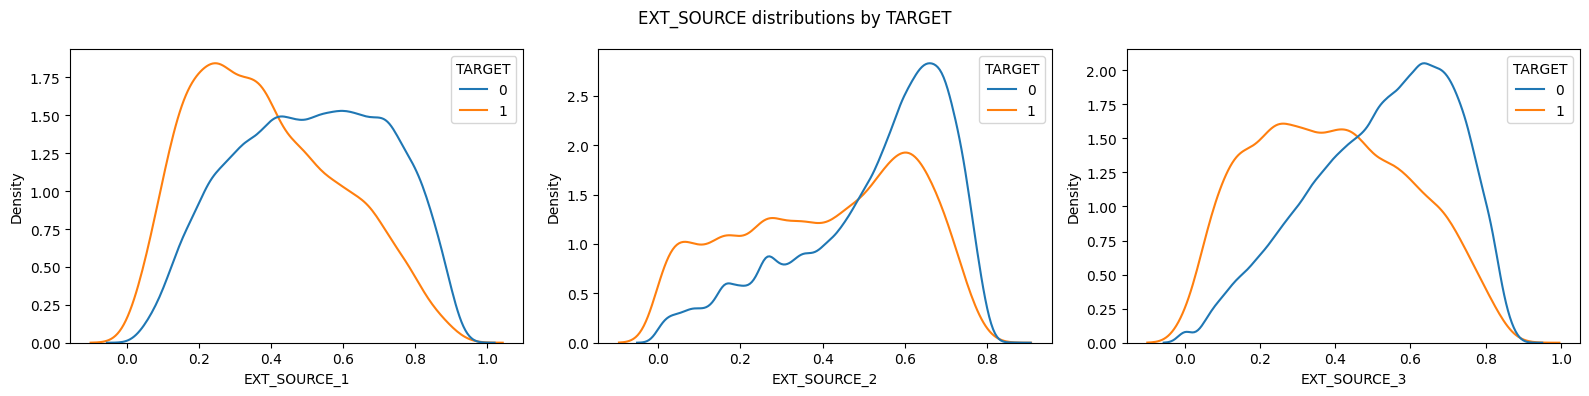

Revolving loans with credit/annuity exactly 20: 16188 of 16214


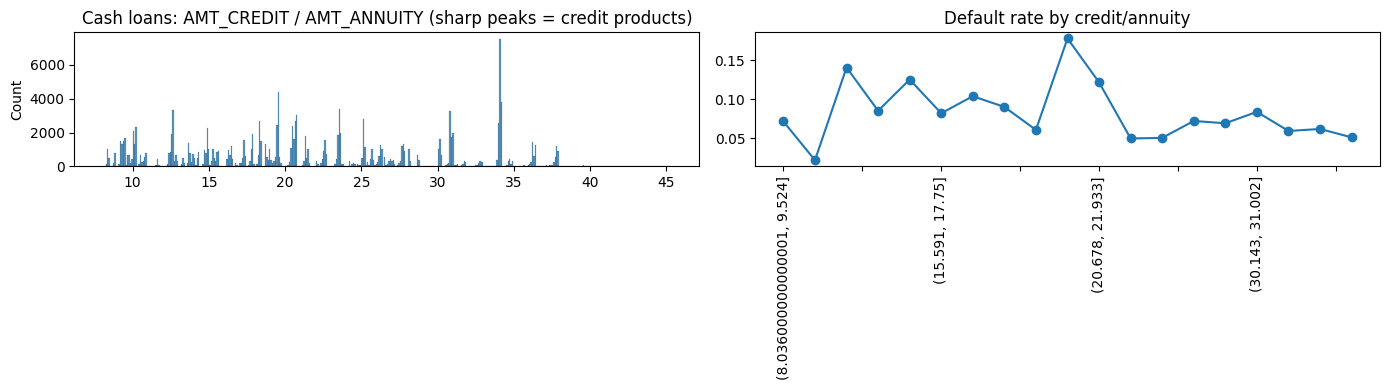

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for a, c in zip(ax, ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]):
    sns.kdeplot(data=train, x=c, hue="TARGET", common_norm=False, ax=a)
plt.suptitle("EXT_SOURCE distributions by TARGET"); plt.tight_layout(); plt.show()

k = train.AMT_CREDIT / train.AMT_ANNUITY
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(k[train.NAME_CONTRACT_TYPE == "Cash loans"], bins=400, ax=ax[0])
ax[0].set_title("Cash loans: AMT_CREDIT / AMT_ANNUITY (sharp peaks = credit products)")
print("Revolving loans with credit/annuity exactly 20:",
      ((k.round(4) == 20) & (train.NAME_CONTRACT_TYPE == "Revolving loans")).sum(), "of",
      (train.NAME_CONTRACT_TYPE == "Revolving loans").sum())
train.groupby(pd.qcut(k, 20, duplicates="drop"), observed=True)["TARGET"].mean().plot(ax=ax[1], marker="o")
ax[1].set_title("Default rate by credit/annuity"); ax[1].tick_params(axis="x", rotation=90)
plt.tight_layout(); plt.show()

* Revolving loans always have annuity = 5% of the credit limit (ratio exactly 20) — they carry no term information.
* For cash loans the ratio `credit / annuity` has sharp spikes and a non-monotonic relation with default: it encodes the
  **loan term and interest rate** of the product, which we recover in Section 4.2.

## 4. Feature engineering
Train and test are processed together for **target-free** transformations only.
### 4.1 Cleaning, domain ratios, EXT_SOURCE aggregates, group-relative features

In [9]:
def build_features(train, test):
    df = pd.concat([train.drop(columns="TARGET"), test], ignore_index=True)
    # cleaning
    df.loc[df.DAYS_EMPLOYED == 365243, "DAYS_EMPLOYED"] = np.nan
    df.loc[df.OWN_CAR_AGE >= 60, "OWN_CAR_AGE"] = np.nan
    df.loc[df.CODE_GENDER == "XNA", "CODE_GENDER"] = np.nan
    df.loc[df.DAYS_LAST_PHONE_CHANGE == 0, "DAYS_LAST_PHONE_CHANGE"] = np.nan
    # external scores
    e = df[["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]]
    df["EXT_MEAN"] = e.mean(axis=1); df["EXT_STD"] = e.std(axis=1)
    df["EXT_MIN"] = e.min(axis=1);   df["EXT_MAX"] = e.max(axis=1)
    df["EXT_PROD"] = e.prod(axis=1, min_count=3)
    df["EXT_NAN"] = e.isna().sum(axis=1)
    df["EXT_W"] = (2 * df.EXT_SOURCE_1.fillna(df.EXT_MEAN) + df.EXT_SOURCE_2.fillna(df.EXT_MEAN)
                   + 3 * df.EXT_SOURCE_3.fillna(df.EXT_MEAN)) / 6
    # loan / income ratios
    df["CREDIT_ANNUITY"] = df.AMT_CREDIT / df.AMT_ANNUITY
    df["CREDIT_GOODS"] = df.AMT_CREDIT / df.AMT_GOODS_PRICE
    df["CREDIT_GOODS_DIFF"] = df.AMT_CREDIT - df.AMT_GOODS_PRICE
    df["ANNUITY_INCOME"] = df.AMT_ANNUITY / df.AMT_INCOME_TOTAL
    df["CREDIT_INCOME"] = df.AMT_CREDIT / df.AMT_INCOME_TOTAL
    df["INCOME_PER_PERSON"] = df.AMT_INCOME_TOTAL / df.CNT_FAM_MEMBERS
    df["CHILD_RATIO"] = df.CNT_CHILDREN / df.CNT_FAM_MEMBERS
    # time ratios
    df["EMPLOYED_BIRTH"] = df.DAYS_EMPLOYED / df.DAYS_BIRTH
    df["REG_BIRTH"] = df.DAYS_REGISTRATION / df.DAYS_BIRTH
    df["ID_BIRTH"] = df.DAYS_ID_PUBLISH / df.DAYS_BIRTH
    df["PHONE_BIRTH"] = df.DAYS_LAST_PHONE_CHANGE / df.DAYS_BIRTH
    df["CAR_BIRTH"] = df.OWN_CAR_AGE / (df.DAYS_BIRTH / -365)
    # date-invariant quantities: the client's age (days) when each event happened
    df["AGE_AT_ID"] = df.DAYS_BIRTH - df.DAYS_ID_PUBLISH
    df["AGE_AT_REG"] = df.DAYS_BIRTH - df.DAYS_REGISTRATION
    df["AGE_AT_EMP"] = df.DAYS_BIRTH - df.DAYS_EMPLOYED
    df["EXT_x_CREDIT_ANN"] = df.EXT_MEAN * df.CREDIT_ANNUITY
    df["DOC_NAN"] = df[["AMT_REQ_CREDIT_BUREAU_YEAR"]].isna().sum(axis=1)
    # value relative to peers of the same group
    for g in ["ORGANIZATION_TYPE", "OCCUPATION_TYPE", "NAME_EDUCATION_TYPE", "NAME_INCOME_TYPE"]:
        for c in ["AMT_INCOME_TOTAL", "EXT_MEAN", "CREDIT_ANNUITY", "ANNUITY_INCOME"]:
            df[f"{c}_rel_{g}"] = df[c] / df.groupby(g)[c].transform("median")
    # count encoding + native categorical dtype
    for c in CAT:
        df[c + "_CNT"] = df[c].map(df[c].value_counts())
        df[c] = df[c].astype("category")
    return df

ALL = build_features(train, test)
ALL.shape

(232702, 81)

### 4.2 Annuity math: recovering the loan term and the interest rate
For principal $P$, monthly rate $r$ and $n$ monthly payments, the annuity is

$$A = P\,\frac{r}{1-(1+r)^{-n}} \quad\Longleftrightarrow\quad k \equiv \frac{P}{A} = \frac{1-(1+r)^{-n}}{r} \equiv a_n(r).$$

$a_n(r)$ is strictly decreasing in $r$ with $a_n(0^+) = n$, so for a given term $n$ a non-negative rate exists **iff $k < n$**, and it
is unique; we find it by **bisection** (60 halvings → precision $2^{-60}$).

We observe $k$ = `AMT_CREDIT / AMT_ANNUITY` but not $n$. Two complementary estimates of the term:

* **(b) Ceiling term (main one).** Home Credit sells loans with standard terms $\{6,10,12,18,24,30,36,42,48,54,60,72\}$ months.
  Since $k<n$ must hold, the *shortest standard term longer than $k$* is the most plausible one, and it produces realistic rates
  (e.g. $k=34.20 \Rightarrow n=36$, 3.4%/year promotional product; $k=20.46 \Rightarrow n=24$, 17%/year; $k=10.21 \Rightarrow n=12$, 36%/year).
  From it: `RATE_CEIL`, `TERM_GAP = n − k`, total interest paid $nA - P$ and interest relative to income.
* **(a) Most frequent rate.** For every candidate $n$, the implied annual rate is rounded and the term whose rate is shared by the
  most loans (= an existing product) is kept.

These are highly irregular functions of $k$ (they depend on the discrete term grid and on global frequencies), which trees cannot learn
from $k$ alone; adding them improved CV AUC by about **+0.003**.

In [10]:
def solve_rate(k, n, iters=60):
    # monthly rate r with a_n(r) = k, by bisection; NaN when k >= n (no non-negative solution)
    k = np.asarray(k, float)
    lo = np.full_like(k, 1e-9); hi = np.full_like(k, 1.0)
    for _ in range(iters):
        mid = (lo + hi) / 2
        f = (1 - (1 + mid) ** -n) / mid - k        # decreasing in mid
        lo = np.where(f > 0, mid, lo); hi = np.where(f > 0, hi, mid)
    r = (lo + hi) / 2
    return np.where((k < n) & np.isfinite(k), r, np.nan)

def count_of(values):
    s = pd.Series(values)
    return s.map(s.value_counts()).to_numpy(dtype=float, copy=True)

FREQ_TERMS = [6, 10, 12, 18, 24, 30, 36, 42, 48, 54, 60]
STD_TERMS = np.array([6, 10, 12, 18, 24, 30, 36, 42, 48, 54, 60, 72])

def rate_features(df):
    out = pd.DataFrame(index=df.index)
    k = (df.AMT_CREDIT / df.AMT_ANNUITY).values
    # (a) most frequent implied rate
    out["K_CNT"] = count_of(np.round(k, 3))
    out["CG_CNT"] = count_of(np.round((df.AMT_CREDIT / df.AMT_GOODS_PRICE).values, 3))
    freqs, rates = [], []
    for n in FREQ_TERMS:
        r = solve_rate(k, n)
        annual = np.round((1 + r) ** 12 - 1, 3)
        f = count_of(annual); f[np.isnan(annual)] = 0
        freqs.append(f); rates.append(r)
    F, R = np.vstack(freqs).T, np.vstack(rates).T
    best = F.argmax(axis=1)
    out["TERM_INF"] = np.array(FREQ_TERMS, float)[best]
    out["TERM_INF_FREQ"] = F.max(axis=1)
    out["RATE_INF"] = (1 + R[np.arange(len(k)), best]) ** 12 - 1
    out.loc[F.max(axis=1) == 0, ["TERM_INF", "RATE_INF"]] = np.nan
    out["KG_CNT"] = count_of(np.round((df.AMT_GOODS_PRICE / df.AMT_ANNUITY).values, 3))
    out["TOTAL_PAID_RATIO"] = out.TERM_INF * df.AMT_ANNUITY.values / df.AMT_CREDIT.values
    # (b) ceiling standard term (cash loans only)
    idx = np.searchsorted(STD_TERMS, k, side="right")
    ok = np.isfinite(k) & (idx < len(STD_TERMS)) & (df.NAME_CONTRACT_TYPE.astype(str).values == "Cash loans")
    n_c = np.where(ok, STD_TERMS[np.minimum(idx, len(STD_TERMS) - 1)], np.nan)
    kg = (df.AMT_GOODS_PRICE / df.AMT_ANNUITY).values
    r_c = np.full(len(k), np.nan); r_g = np.full(len(k), np.nan)
    for t in np.unique(n_c[ok]):
        m = n_c == t
        r_c[m] = solve_rate(k[m], t)
        mg = m & (kg < t)
        r_g[mg] = solve_rate(kg[mg], t)            # same term, principal = goods price (no insurance)
    out["TERM_CEIL"] = n_c
    out["RATE_CEIL"] = (1 + r_c) ** 12 - 1
    out["TERM_GAP"] = n_c - k
    out["INTEREST_TOTAL"] = n_c * df.AMT_ANNUITY.values - df.AMT_CREDIT.values
    out["INTEREST_INCOME"] = out.INTEREST_TOTAL / df.AMT_INCOME_TOTAL.values
    out["RATE_x_EXT"] = out.RATE_CEIL * df.EXT_MEAN.values
    out["RATE_CEIL_GOODS"] = (1 + r_g) ** 12 - 1
    return out

RF = rate_features(ALL)
RF.describe().T[["mean", "50%", "min", "max"]].round(3)

,mean,50%,min,max
K_CNT,2237.548,100.000,1.000,21892.000
CG_CNT,34733.355,17925.000,1.000,81218.000
TERM_INF,40.614,42.000,10.000,60.000
TERM_INF_FREQ,3242.810,786.000,1.000,21894.000
RATE_INF,0.536,0.486,0.000,2.859
KG_CNT,2100.153,57.000,1.000,21409.000
TOTAL_PAID_RATIO,1.991,1.800,1.000,7.154
TERM_CEIL,24.832,24.000,10.000,48.000
RATE_CEIL,0.179,0.131,0.000,0.719
TERM_GAP,3.075,3.141,0.001,6.000


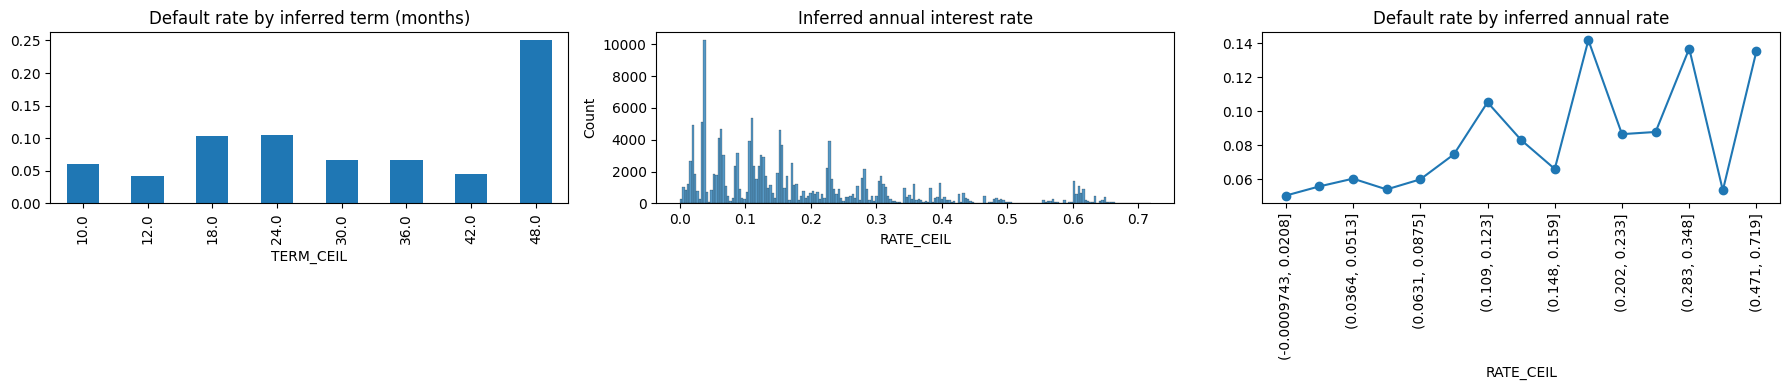

In [11]:
tmp = RF.iloc[:n_train].assign(TARGET=y)
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
tmp.groupby("TERM_CEIL")["TARGET"].mean().plot.bar(ax=ax[0], title="Default rate by inferred term (months)")
sns.histplot(tmp.RATE_CEIL.clip(0, 1), bins=200, ax=ax[1]); ax[1].set_title("Inferred annual interest rate")
tmp.groupby(pd.qcut(tmp.RATE_CEIL, 15, duplicates="drop"), observed=True)["TARGET"].mean().plot(ax=ax[2], marker="o")
ax[2].set_title("Default rate by inferred annual rate"); ax[2].tick_params(axis="x", rotation=90)
plt.tight_layout(); plt.show()

### 4.3 Model-based imputation of EXT_SOURCE (target-free)
`EXT_SOURCE_1` is missing for 70% of the clients but it is partly predictable from the other attributes (age, employment,
the other two scores...). For each score we train a LightGBM **regressor** on the rows where it is known (5-fold, so known rows get
out-of-fold predictions) and predict it everywhere. `TARGET` is never used, so this cannot leak. We add the prediction, the
filled-in score and aggregates of the filled scores.

In [12]:
def ext_impute_features(ALL, seed=0):
    ext = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
    derived = [c for c in ALL.columns if c.startswith("EXT_") or "EXT_MEAN" in c]
    base = [c for c in ALL.columns if c not in derived + ["SK_ID_CURR", "FLAG_MOBIL"]]
    p = dict(objective="regression", learning_rate=0.05, num_leaves=63, min_child_samples=50,
             colsample_bytree=0.7, subsample=0.8, subsample_freq=1, verbose=-1, n_jobs=N_JOBS, seed=seed)
    out = pd.DataFrame(index=ALL.index)
    for e in ext:
        feats = base + [x for x in ext if x != e]
        known = ALL[e].notna().values
        idx_known = np.where(known)[0]
        Xk, yk = ALL.loc[known, feats], ALL.loc[known, e].values
        pred = np.zeros(len(ALL)); unk = np.zeros((~known).sum())
        for a, b in KFold(5, shuffle=True, random_state=seed).split(Xk):
            m = lgb.train(p, lgb.Dataset(Xk.iloc[a], yk[a]), 600)
            pred[idx_known[b]] = m.predict(Xk.iloc[b])
            unk += m.predict(ALL.loc[~known, feats]) / 5
        pred[~known] = unk
        out[e + "_PRED"] = pred
        out[e + "_FILL"] = ALL[e].fillna(pd.Series(pred, index=ALL.index))
        print(f"{e}: out-of-fold R2 = {1 - np.mean((pred[known] - yk) ** 2) / np.var(yk):.3f}")
    f = out[[e + "_FILL" for e in ext]]
    out["EXTF_MEAN"] = f.mean(axis=1); out["EXTF_MIN"] = f.min(axis=1); out["EXTF_PROD"] = f.prod(axis=1)
    out["EXTF_W"] = (2 * f.iloc[:, 0] + f.iloc[:, 1] + 3 * f.iloc[:, 2]) / 6
    return out

t0 = time.time()
EI = ext_impute_features(ALL)          # uses only the basic features of 4.1
ALL = pd.concat([ALL, RF, EI], axis=1)
print(f"done in {time.time() - t0:.0f}s, shape {ALL.shape}")

EXT_SOURCE_1: out-of-fold R2 = 0.484


EXT_SOURCE_2: out-of-fold R2 = 0.248


EXT_SOURCE_3: out-of-fold R2 = 0.139
done in 86s, shape (232702, 105)


### 4.4 Same-person features
`DAYS_BIRTH`, `DAYS_ID_PUBLISH`, `DAYS_REGISTRATION` and `DAYS_EMPLOYED` are all counted **backwards from the application date**.
Their differences — e.g. `DAYS_BIRTH − DAYS_ID_PUBLISH`, the client's age (in days) when the ID document was issued — do **not**
depend on when the application was made. Together with gender they form a fingerprint of the client, which lets us find other
applications of the same person (~3% of rows). Their history is very informative:

In [13]:
PERSON_KEYS = {
    "P1": ["CODE_GENDER", "AGE_AT_ID", "AGE_AT_REG"],
    "P2": ["CODE_GENDER", "AGE_AT_ID", "AGE_AT_REG", "AGE_AT_EMP"],
    "P3": ["AGE_AT_ID", "AGE_AT_REG"],
}

def person_key(df, cols):
    ok = df[cols].notna().all(axis=1).values
    kk = pd.util.hash_pandas_object(df[cols], index=False).values.astype(np.int64)
    return np.where(ok, kk, -np.arange(len(df)) - 1)   # incomplete keys never match

for name, cols in PERSON_KEYS.items():
    kk = person_key(ALL.iloc[:n_train], cols)
    s = pd.Series(y).groupby(kk).transform("sum").values
    c = pd.Series(y).groupby(kk).transform("count").values
    m = c > 1
    other = (s - y) / np.maximum(c - 1, 1)
    print(f"{name}: train rows with another train application = {m.sum():5d} | "
          f"P(default | other defaulted) = {y[m & (other > 0)].mean():.3f} | "
          f"P(default | other repaid) = {y[m & (other == 0)].mean():.3f}")

P1: train rows with another train application =  5462 | P(default | other defaulted) = 0.250 | P(default | other repaid) = 0.048


P2: train rows with another train application =  1930 | P(default | other defaulted) = 0.437 | P(default | other repaid) = 0.047
P3: train rows with another train application =  6719 | P(default | other defaulted) = 0.208 | P(default | other repaid) = 0.055


In [14]:
def person_features(df, y, n_train, label_mask=None):
    # label_mask: train rows whose labels may be used (= training folds). A row never uses its own label.
    out = pd.DataFrame(index=df.index)
    yy = np.full(len(df), np.nan); yy[:n_train] = y
    if label_mask is not None:
        m = np.zeros(len(df), bool); m[:n_train] = label_mask; yy[~m] = np.nan
    lab = ~np.isnan(yy); y0 = np.where(lab, yy, 0)
    db = df.DAYS_BIRTH.values
    for name, cols in PERSON_KEYS.items():
        kk = person_key(df, cols); ks = pd.Series(kk)
        out[name + "_N"] = ks.map(ks.value_counts()).values - 1                 # other applications
        S = pd.Series(y0).groupby(kk).transform("sum").values - y0
        Cn = pd.Series(lab.astype(float)).groupby(kk).transform("sum").values - lab
        out[name + "_YSUM"] = np.where(Cn > 0, S, np.nan)                        # defaults on the other ones
        out[name + "_YMEAN"] = np.where(Cn > 0, S / np.maximum(Cn, 1), np.nan)
        gmin = pd.Series(db).groupby(kk).transform("min").values
        gmax = pd.Series(db).groupby(kk).transform("max").values
        has = out[name + "_N"].values > 0
        out[name + "_RANK"] = np.where(has, db - gmin, np.nan)                  # days since first application
        out[name + "_SPAN"] = np.where(has, gmax - gmin, np.nan)
    return out

### 4.5 Feature selection and fold matrices
A first LightGBM fit (gain importance summed over the 5 folds) showed 15 features with (almost) no contribution — redundant
encodings (e.g. `NAME_CONTRACT_TYPE` is already implied by `TERM_CEIL` being NaN) and duplicated person counts. Removing them
improved CV from 0.7682 to 0.7686, so they are dropped.

For every fold the same-person features are recomputed using **only that fold's training labels**; the test set uses all train labels.

In [15]:
DROP = ["SK_ID_CURR", "FLAG_MOBIL",
        "NAME_CONTRACT_TYPE", "NAME_CONTRACT_TYPE_CNT", "FLAG_EMP_PHONE", "P3_N", "P1_N", "P2_N", "DOC_NAN",
        "CHILD_RATIO", "P2_YSUM", "AMT_REQ_CREDIT_BUREAU_HOUR", "NAME_INCOME_TYPE", "P2_YMEAN", "P2_SPAN",
        "CNT_CHILDREN", "NAME_INCOME_TYPE_CNT"]

folds = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED).split(np.zeros(n_train), y))
X_base = ALL.iloc[:n_train].reset_index(drop=True)
P_test = person_features(ALL, y, n_train).iloc[n_train:].reset_index(drop=True)
X_test = pd.concat([ALL.iloc[n_train:].reset_index(drop=True), P_test], axis=1)
features = [c for c in X_test.columns if c not in DROP]
X_test = X_test[features]

fold_data = []
for tr_idx, va_idx in folds:
    mask = np.zeros(n_train, bool); mask[tr_idx] = True
    P = person_features(ALL, y, n_train, label_mask=mask).iloc[:n_train].reset_index(drop=True)
    fold_data.append(pd.concat([X_base, P], axis=1)[features])
print("number of features:", len(features))

number of features: 103


## 5. Models
Three gradient-boosting libraries with different tree-growing strategies (leaf-wise LightGBM, depth-wise XGBoost, symmetric
CatBoost with ordered target statistics) → diverse errors for the ensemble. Each one produces out-of-fold (OOF) predictions for the
train set and the average of the 5 fold models for the test set.

In [16]:
oof, pred = {}, {}

### 5.1 LightGBM (3 seeds)
Small, strongly regularised trees (15 leaves, ≥200 rows per leaf, 40% of the features per tree) were the best in the tuning experiments.

In [17]:
LGB_PARAMS = dict(objective="binary", learning_rate=0.02, num_leaves=15, min_child_samples=200, colsample_bytree=0.4,
                  subsample=0.8, subsample_freq=1, reg_lambda=5, reg_alpha=1, cat_smooth=50, min_data_per_group=200,
                  verbose=-1, n_jobs=N_JOBS)
LGB_SEEDS = [0, 1, 2]

def run_lgb(params, seeds, name):
    t0 = time.time()
    o, p = np.zeros(n_train), np.zeros(len(X_test)); imp = pd.Series(0.0, index=features)
    for s in seeds:
        for i, (tr_idx, va_idx) in enumerate(folds):
            Xf = fold_data[i]
            m = lgb.train({**params, "seed": s}, lgb.Dataset(Xf.loc[tr_idx], y[tr_idx]), 20000,
                          valid_sets=[lgb.Dataset(Xf.loc[va_idx], y[va_idx])],
                          callbacks=[lgb.early_stopping(300, verbose=False)])
            o[va_idx] += m.predict(Xf.loc[va_idx], num_iteration=m.best_iteration) / len(seeds)
            p += m.predict(X_test, num_iteration=m.best_iteration) / (len(folds) * len(seeds))
            imp += m.feature_importance("gain")
    print(f"{name}: OOF AUC {roc_auc_score(y, o):.5f}  ({(time.time() - t0) / 60:.1f} min)")
    return o, p, imp

oof["lgb"], pred["lgb"], importances = run_lgb(LGB_PARAMS, LGB_SEEDS, "LightGBM")

LightGBM: OOF AUC 0.76903  (3.2 min)


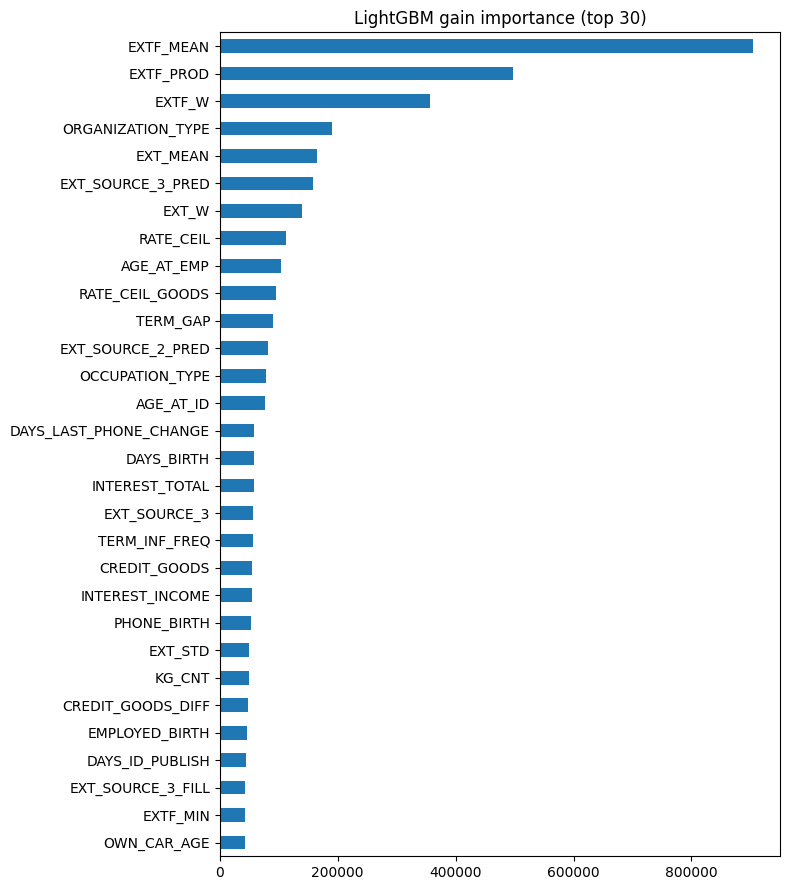

In [18]:
importances.sort_values(ascending=False).head(30)[::-1].plot.barh(figsize=(8, 9), title="LightGBM gain importance (top 30)")
plt.tight_layout(); plt.show()

### 5.1b LightGBM — wider trees, stronger column sampling (diversity)

In [19]:
LGB_B_PARAMS = {**LGB_PARAMS, "num_leaves": 31, "min_child_samples": 400, "colsample_bytree": 0.25,
                "reg_lambda": 20, "learning_rate": 0.015}
oof["lgb_b"], pred["lgb_b"], _ = run_lgb(LGB_B_PARAMS, LGB_SEEDS, "LightGBM-B")

LightGBM-B: OOF AUC 0.76856  (3.4 min)


### 5.2 XGBoost
Depth-wise trees (max depth 4) with native categorical support.

In [20]:
XGB_PARAMS = dict(objective="binary:logistic", eval_metric="auc", eta=0.02, max_depth=4, min_child_weight=30,
                  subsample=0.8, colsample_bytree=0.4, reg_lambda=10, reg_alpha=1, tree_method="hist", max_bin=256,
                  max_cat_to_onehot=1, nthread=N_JOBS, seed=0)
t0 = time.time()
oof["xgb"], pred["xgb"] = np.zeros(n_train), np.zeros(len(X_test))
dtest = xgb.DMatrix(X_test, enable_categorical=True)
for i, (tr_idx, va_idx) in enumerate(folds):
    Xf = fold_data[i]
    dtr = xgb.DMatrix(Xf.loc[tr_idx], y[tr_idx], enable_categorical=True)
    dva = xgb.DMatrix(Xf.loc[va_idx], y[va_idx], enable_categorical=True)
    m = xgb.train(XGB_PARAMS, dtr, 20000, evals=[(dva, "valid")], early_stopping_rounds=300, verbose_eval=False)
    it = (0, m.best_iteration + 1)
    oof["xgb"][va_idx] = m.predict(dva, iteration_range=it)
    pred["xgb"] += m.predict(dtest, iteration_range=it) / len(folds)
    print(f"fold {i}: AUC {roc_auc_score(y[va_idx], oof['xgb'][va_idx]):.5f} (iters {m.best_iteration})")
print(f"XGBoost: OOF AUC {roc_auc_score(y, oof['xgb']):.5f}  ({(time.time() - t0) / 60:.1f} min)")

fold 0: AUC 0.76472 (iters 1431)


fold 1: AUC 0.76873 (iters 2191)


fold 2: AUC 0.77480 (iters 2304)


fold 3: AUC 0.76454 (iters 1558)


fold 4: AUC 0.77003 (iters 1433)
XGBoost: OOF AUC 0.76857  (3.7 min)


### 5.3 CatBoost
Symmetric (oblivious) trees and ordered target statistics for the categorical columns.

In [21]:
def to_cat(df):
    df = df.copy()
    for c in CAT:
        if c in df:
            df[c] = df[c].astype(object).where(df[c].notna(), "NA").astype(str)
    return df

CAT_PARAMS = dict(iterations=3000, learning_rate=0.05, depth=6, l2_leaf_reg=5, eval_metric="AUC",
                  od_type="Iter", od_wait=200, random_seed=0, thread_count=N_JOBS, verbose=0)
cat_cols = [c for c in CAT if c in features]
t0 = time.time()
oof["cat"], pred["cat"] = np.zeros(n_train), np.zeros(len(X_test))
X_test_cb = to_cat(X_test)
for i, (tr_idx, va_idx) in enumerate(folds):
    Xf = to_cat(fold_data[i])
    m = CatBoostClassifier(**CAT_PARAMS)
    m.fit(Xf.loc[tr_idx], y[tr_idx], cat_features=cat_cols, eval_set=(Xf.loc[va_idx], y[va_idx]))
    oof["cat"][va_idx] = m.predict_proba(Xf.loc[va_idx])[:, 1]
    pred["cat"] += m.predict_proba(X_test_cb)[:, 1] / len(folds)
    print(f"fold {i}: AUC {roc_auc_score(y[va_idx], oof['cat'][va_idx]):.5f} (iters {m.get_best_iteration()})")
print(f"CatBoost: OOF AUC {roc_auc_score(y, oof['cat']):.5f}  ({(time.time() - t0) / 60:.1f} min)")

fold 0: AUC 0.76538 (iters 1306)


fold 1: AUC 0.76730 (iters 1008)


fold 2: AUC 0.77193 (iters 1387)


fold 3: AUC 0.76429 (iters 939)


fold 4: AUC 0.76891 (iters 1096)
CatBoost: OOF AUC 0.76753  (15.3 min)


## 6. Ensemble & submission
AUC depends only on the **ordering** of the predictions, so the models are blended on their normalised ranks
(this removes differences in calibration between libraries). The blend weights $w \ge 0,\ \sum w = 1$ maximise the OOF AUC
(Nelder–Mead on a softmax-free parametrisation $w = |v| / \sum |v|$).

In [22]:
names = list(oof)
R = np.column_stack([rankdata(oof[k]) / n_train for k in names])
display(pd.DataFrame(R, columns=names).corr().round(3))
for k in names:
    print(f"{k:6s} OOF AUC {roc_auc_score(y, oof[k]):.5f}")

objective = lambda v: -roc_auc_score(y, R @ (np.abs(v) / np.abs(v).sum()))
res = minimize(objective, np.ones(len(names)) / len(names), method="Nelder-Mead",
               options=dict(maxiter=400, xatol=1e-3, fatol=1e-6))
W = np.abs(res.x) / np.abs(res.x).sum()
print("equal weights  -> OOF AUC", round(-objective(np.ones(len(names))), 5))
print("optimal weights:", dict(zip(names, W.round(3))), "-> OOF AUC", round(-res.fun, 5))

,lgb,lgb_b,xgb,cat
lgb,1.000,0.995,0.992,0.973
lgb_b,0.995,1.000,0.993,0.972
xgb,0.992,0.993,1.000,0.971
cat,0.973,0.972,0.971,1.000


lgb    OOF AUC 0.76903
lgb_b  OOF AUC 0.76856
xgb    OOF AUC 0.76857
cat    OOF AUC 0.76753


equal weights  -> OOF AUC 0.76985
optimal weights: {'lgb': 0.409, 'lgb_b': 0.03, 'xgb': 0.21, 'cat': 0.352} -> OOF AUC 0.76995


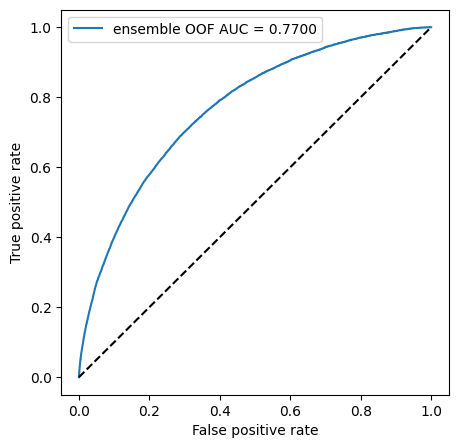

In [23]:
oof_ens = R @ W
fpr, tpr, _ = roc_curve(y, oof_ens)
plt.figure(figsize=(5, 5)); plt.plot(fpr, tpr, label=f"ensemble OOF AUC = {roc_auc_score(y, oof_ens):.4f}")
plt.plot([0, 1], [0, 1], "k--"); plt.xlabel("False positive rate"); plt.ylabel("True positive rate"); plt.legend(); plt.show()

# Final test prediction: same weighted rank blend (values in (0, 1])
pred_final = np.column_stack([rankdata(pred[k]) / len(X_test) for k in names]) @ W
pred = pred_final

### 6.2 Saving the prediction as CSV file [DO NOT CHANGE]

In [24]:
# Put the prediction into the format of submission
sample_sub['TARGET'] = pred
sample_sub

,SK_ID_CURR,TARGET
0,171202,0.309493
1,171203,0.943675
2,171204,0.880012
3,171205,0.687980
4,171206,0.896735
...,...,...
61495,232697,0.847593
61496,232698,0.165444
61497,232699,0.439209
61498,232700,0.944025


In [25]:
# Create the "output" directory if it doesn't exist
output_dir = current_dir / "output"
os.makedirs(output_dir, exist_ok=True)

# Specify the new output file path
output_file = output_dir / "submission.csv"

# Save the CSV file to the "output" directory
sample_sub.to_csv(output_file, index=False)

### 6.3 Saving this notebook as a ZIP file [REQUIREMENT IF AIMING FOR HONORS/OUTSTANDING STUDENTS]
Save the notebook (Ctrl+S / Cmd+S) before running this cell.

In [26]:
import zipfile

notebook_filename = "solution.ipynb"  # name of this notebook
zip_filename = "solution.zip"
notebook_path = current_dir / notebook_filename
zip_output_path = current_dir / zip_filename

if notebook_path.exists():
    with zipfile.ZipFile(zip_output_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        zipf.write(notebook_path, arcname=notebook_filename)
    print(f"Successfully created: {zip_output_path}")
else:
    print(f"Error: Could not find '{notebook_filename}' in {current_dir}.")

Successfully created: solution.zip
